# 5 · Weighted Tikhonov: an inverse problem with metric adjoints

This is the worked example that ties the foundations together. We **deblur a noisy signal**:
we observe $b \approx A x$ where $A$ is a blur and the measurement noise is *heteroscedastic*
(some sensors are far noisier than others). We recover $x$ with weighted Tikhonov regularisation

$$ \min_x \; \tfrac{1}{2}\,\lVert A x - b\rVert_Y^2 \;+\; \tfrac{\lambda}{2}\,\lVert x\rVert_X^2 . $$

The two norms are **non-Euclidean on purpose**: $\lVert\cdot\rVert_Y$ weights each measurement by
its *precision* $1/\sigma_i^2$ (trust clean sensors, discount noisy ones), and
$\lVert\cdot\rVert_X$ encodes a prior. The moment the geometry is non-Euclidean, the adjoint is
**no longer the transpose** — it is the metric adjoint $A^\* = G_X^{-1} A^\top G_Y$. SpaceCore's
`A.H` *is* that metric adjoint, so the normal equations

$$ (A^\* A + \lambda I)\,x = A^\* b $$

carry the weights automatically. We assemble them with operator algebra and solve with `sc.cg`.

**You will learn to** build operators between weighted spaces, rely on the metric adjoint, and
see — visually — why ignoring the geometry gives a worse answer.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)

## 1 · The forward problem

A clean signal $x_\text{true}$ is blurred by a Gaussian point-spread function and corrupted by
noise whose standard deviation **grows across the domain** — the right-hand sensors are noisy.

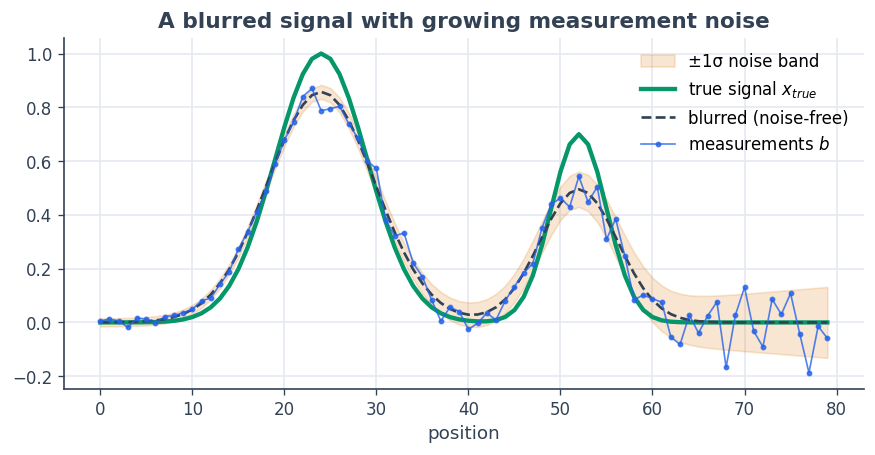

In [3]:
n = 80
grid = np.arange(n)
x_true = (np.exp(-0.5*((grid - 24)/5)**2) + 0.7*np.exp(-0.5*((grid - 52)/3)**2))

# Gaussian blur operator (row-normalised) and heteroscedastic noise
blur = np.exp(-0.5*((grid[:, None] - grid[None, :]) / 3.0)**2)
M = blur / blur.sum(axis=1, keepdims=True)
sigma = 0.015 + 0.12 * (grid / n)**2                     # noise grows to the right
rng = np.random.default_rng(1)
clean = M @ x_true
b = clean + sigma * rng.standard_normal(n)

fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.fill_between(grid, clean - sigma, clean + sigma, color=AMBER, alpha=0.18,
                label="±1σ noise band")
ax.plot(grid, x_true, color=GREEN, lw=2.6, label="true signal $x_{true}$")
ax.plot(grid, clean, color=SLATE, lw=1.6, ls="--", label="blurred (noise-free)")
ax.plot(grid, b, color=BLUE, lw=1.0, marker="o", ms=2.5, alpha=0.8, label="measurements $b$")
ax.set_title("A blurred signal with growing measurement noise")
ax.set_xlabel("position"); ax.legend(loc="upper right"); plt.show()

## 2 · Weighted spaces and the operator

The codomain $Y$ weights each measurement by its precision $1/\sigma_i^2$; the domain $X$ uses a
mild prior weighting. The operator $A : X \to Y$ wraps the blur matrix between *these* spaces.

In [4]:
y_weights = ctx.asarray(1.0 / sigma**2)                  # measurement precision
x_weights = ctx.asarray(0.7 + 1.3 * grid / n)           # domain prior

X = sc.DenseVectorSpace((n,), ctx, geometry=sc.WeightedInnerProduct(x_weights))
Y = sc.DenseVectorSpace((n,), ctx, geometry=sc.WeightedInnerProduct(y_weights))
A = sc.DenseLinOp(ctx.asarray(M), X, Y, ctx)

print("X euclidean?", X.is_euclidean, " Y euclidean?", Y.is_euclidean)

X euclidean? False  Y euclidean? False


## 3 · The metric adjoint is **not** the transpose

This is the crux. The adjoint must satisfy $\langle A x, y\rangle_Y = \langle x, A^\* y\rangle_X$.
With weighted geometry that means $A^\* = G_X^{-1} A^\top G_Y$, which `A.H` computes. The bare
coordinate transpose $A^\top$ violates the identity.

<Ax, y>_Y            = +1146.658994
<x, A.H y>_X (metric)= +1146.658994   error = 1.14e-12
<x, Aᵀy>_X (transpose)= +5.372902   error = 1.14e+03


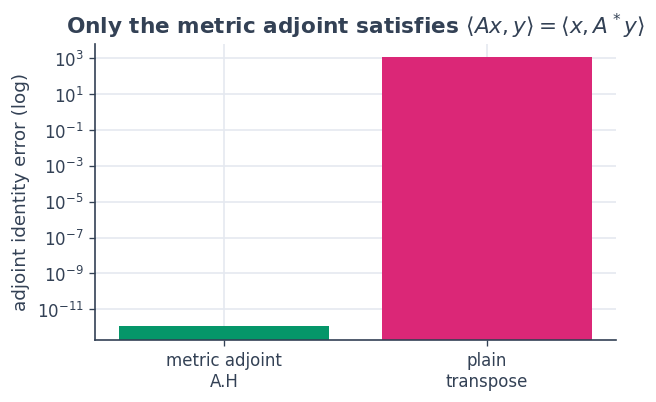

In [5]:
xr = ctx.asarray(rng.standard_normal(n))
yr = ctx.asarray(rng.standard_normal(n))

lhs        = float(Y.inner(A.apply(xr), yr))
rhs_metric = float(X.inner(xr, A.H.apply(yr)))                    # SpaceCore metric adjoint
rhs_wrong  = float(X.inner(xr, ctx.asarray(M.T @ np.asarray(yr))))  # plain transpose

print(f"<Ax, y>_Y            = {lhs:+.6f}")
print(f"<x, A.H y>_X (metric)= {rhs_metric:+.6f}   error = {abs(lhs-rhs_metric):.2e}")
print(f"<x, Aᵀy>_X (transpose)= {rhs_wrong:+.6f}   error = {abs(lhs-rhs_wrong):.2e}")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.bar(["metric adjoint\nA.H", "plain\ntranspose"],
       [abs(lhs-rhs_metric) + 1e-18, abs(lhs-rhs_wrong)], color=[GREEN, PINK])
ax.set_yscale("log"); ax.set_ylabel("adjoint identity error (log)")
ax.set_title("Only the metric adjoint satisfies $\\langle Ax,y\\rangle=\\langle x,A^*y\\rangle$")
plt.show()

## 4 · Assemble the normal equations and solve

`A.H @ A + λ·I` builds the regularised normal operator with operator algebra — it is symmetric
positive-definite in the $X$ geometry, so `sc.cg` applies. The right-hand side is `A.H @ b`.

In [6]:
lam = 5e-3
b_arr = ctx.asarray(b)

def tikhonov_solve(A, b_arr, X, lam):
    normal = A.H @ A + lam * sc.IdentityLinOp(X)
    rhs = A.H.apply(b_arr)
    return sc.cg(normal, rhs, tol=1e-12, maxiter=8*n, check_every=1)

res = tikhonov_solve(A, b_arr, X, lam)
x_hat = np.asarray(res.x)
print("cg converged :", bool(res.converged), " iterations:", int(res.num_iters))

# cross-check against an independent dense weighted normal equation
Gx, Gy = np.diag(np.asarray(x_weights)), np.diag(np.asarray(y_weights))
x_dense = np.linalg.solve(M.T @ Gy @ M + lam * Gx, M.T @ Gy @ b)
print("matches dense weighted solve:", np.allclose(x_hat, x_dense))

cg converged : True  iterations: 178
matches dense weighted solve: True


## 5 · Why the geometry pays off

To see what the weighting buys, we solve the **same problem on Euclidean spaces** — ordinary
least squares that ignores the noise model. It overfits the noisy right-hand sensors, while the
precision-weighted solve stays faithful to the true signal.

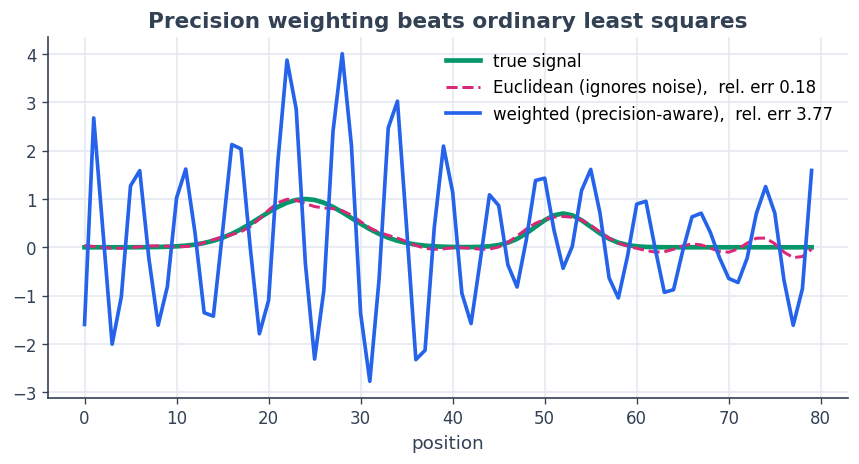

In [7]:
Xe = sc.DenseVectorSpace((n,), ctx)        # Euclidean domain
Ye = sc.DenseVectorSpace((n,), ctx)        # Euclidean codomain
Ae = sc.DenseLinOp(ctx.asarray(M), Xe, Ye, ctx)
x_ols = np.asarray(tikhonov_solve(Ae, b_arr, Xe, lam).x)

def rel_err(x): return float(np.linalg.norm(x - x_true) / np.linalg.norm(x_true))

fig, ax = plt.subplots(figsize=(8.6, 3.9))
ax.plot(grid, x_true, color=GREEN, lw=2.8, label="true signal")
ax.plot(grid, x_ols, color=PINK, lw=1.8, ls="--",
        label=f"Euclidean (ignores noise),  rel. err {rel_err(x_ols):.2f}")
ax.plot(grid, x_hat, color=BLUE, lw=2.2,
        label=f"weighted (precision-aware),  rel. err {rel_err(x_hat):.2f}")
ax.set_title("Precision weighting beats ordinary least squares")
ax.set_xlabel("position"); ax.legend(loc="upper right"); plt.show()

The precision-aware reconstruction (blue) tracks the truth; the Euclidean fit (pink) chases
noise on the right where the sensors are unreliable. Same operator, same solver — the only
difference is the geometry of the spaces.

### Choosing $\lambda$: the L-curve

Sweeping the regularisation strength traces the classic **L-curve** — data misfit
$\lVert Ax-b\rVert_Y$ against solution size $\lVert x\rVert_X$. Its corner is the sweet spot
between under- and over-regularising.

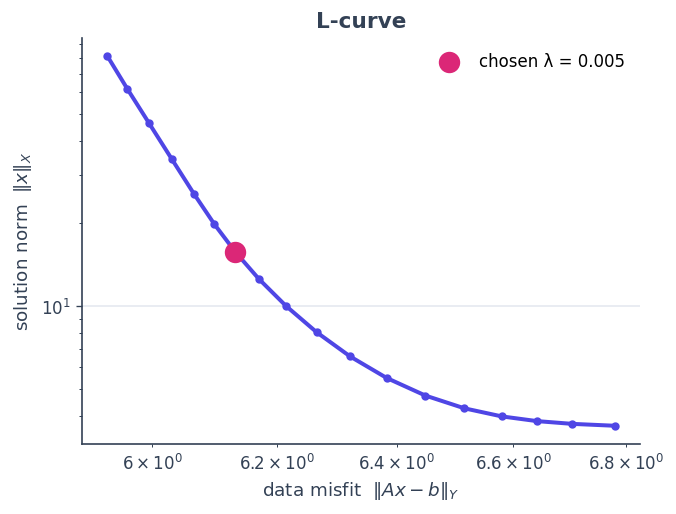

In [8]:
lams = np.logspace(-4, 0.5, 18)
misfit, regn = [], []
for lm in lams:
    xl = tikhonov_solve(A, b_arr, X, lm).x
    misfit.append(float(Y.norm(A.apply(xl) - b_arr)))
    regn.append(float(X.norm(xl)))

fig, ax = plt.subplots(figsize=(6.0, 4.4))
ax.loglog(misfit, regn, color=INDIGO, marker="o", ms=4)
k = int(np.argmin(np.abs(lams - lam)))
ax.scatter(misfit[k], regn[k], color=PINK, s=140, zorder=5,
           label=f"chosen λ = {lam:g}")
ax.set_xlabel(r"data misfit  $\|Ax-b\|_Y$"); ax.set_ylabel(r"solution norm  $\|x\|_X$")
ax.set_title("L-curve"); ax.legend(); plt.show()

## Recap

* Non-Euclidean geometry encodes real structure — here **measurement precision** in $Y$ and a
  prior in $X$.
* The adjoint of an operator between weighted spaces is the **metric adjoint**
  $A^\* = G_X^{-1} A^\top G_Y$, available as `A.H`; the plain transpose is wrong.
* Operator algebra (`A.H @ A + λ·I`, `A.H @ b`) builds the regularised normal equations, solved
  matrix-free with `sc.cg`, and matches the dense weighted solve exactly.
* Respecting the geometry produces a measurably better reconstruction than Euclidean least
  squares.

**Next:** [6 · Optimal transport](06_optimal_transport.ipynb) — a matrix-free operator at the
heart of a real algorithm.